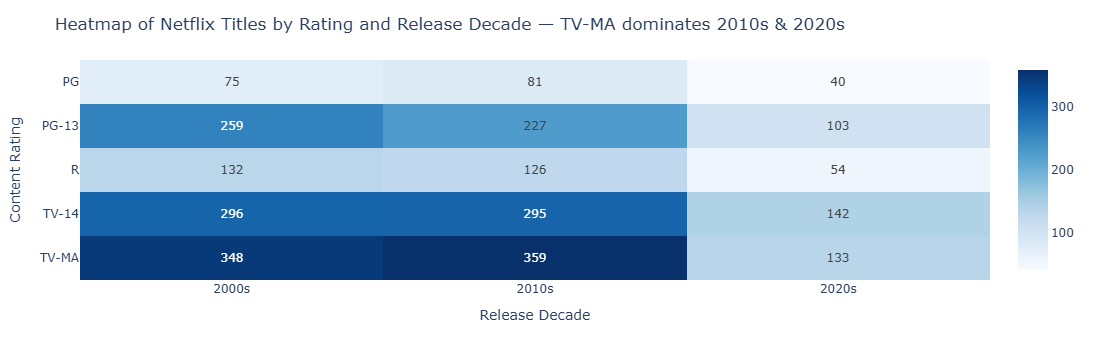

In [1]:
import pandas as pd
import plotly.express as px

# Load data
df = pd.read_csv("netflix_catalogue.csv")

# Create decade column
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

# Filter to required ratings
ratings_to_keep = ['TV-14', 'TV-MA', 'PG-13', 'R', 'PG']
df_filtered = df[df['rating'].isin(ratings_to_keep)]

# Group by rating + decade
heatmap_data = df_filtered.groupby(['rating', 'decade']).size().reset_index(name='count')

# Pivot for heatmap
heatmap_pivot = heatmap_data.pivot(index='rating', columns='decade', values='count').fillna(0)

# Build heatmap
fig = px.imshow(
    heatmap_pivot,
    text_auto=True,
    color_continuous_scale='Blues',
    aspect='auto'
)

fig.update_layout(
    title="Heatmap of Netflix Titles by Rating and Release Decade — TV-MA dominates 2010s & 2020s",
    xaxis_title="Release Decade",
    yaxis_title="Content Rating"
)

fig.show()


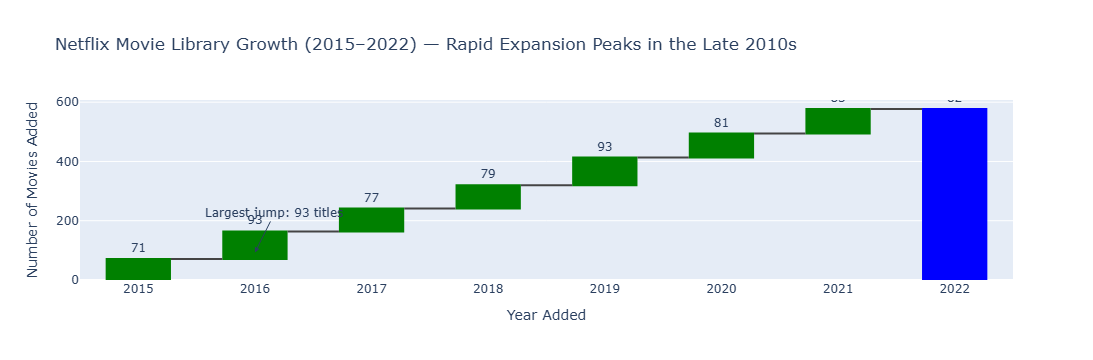

In [2]:
import pandas as pd
import plotly.graph_objects as go

# Load data
df = pd.read_csv("netflix_catalogue.csv")

# Filter to Movies only
movies = df[df['type'] == 'Movie']

# Restrict to 2015–2022
movies = movies[(movies['added_year'] >= 2015) & (movies['added_year'] <= 2022)]

# Count movies added per year
yearly = movies.groupby('added_year').size().reset_index(name='count')

# Compute cumulative total
yearly['cumulative'] = yearly['count'].cumsum()

# Identify the year with the largest single-year addition
max_year = yearly.loc[yearly['count'].idxmax(), 'added_year']
max_value = yearly['count'].max()

# Build waterfall components
measure = ['relative'] * len(yearly)
measure[-1] = 'total'  # final bar is total

fig = go.Figure(go.Waterfall(
    name="Movie Additions",
    orientation="v",
    x=yearly['added_year'],
    y=yearly['count'],
    measure=measure,
    increasing={"marker": {"color": "green"}},
    totals={"marker": {"color": "blue"}},
    text=yearly['count'],
    textposition="outside"
))

# Add annotation for largest addition
fig.add_annotation(
    x=max_year,
    y=max_value,
    text=f"Largest jump: {max_value} titles",
    showarrow=True,
    arrowhead=2,
    ax=20,
    ay=-40
)

fig.update_layout(
    title="Netflix Movie Library Growth (2015–2022) — Rapid Expansion Peaks in the Late 2010s",
    xaxis_title="Year Added",
    yaxis_title="Number of Movies Added",
    waterfallgroupgap=0.3
)

fig.show()
